# Row 2: The live GEX level at 10:00 predicts the rest-of-day range

| field | content |
|---|---|
| frequency (GEX period) | live value at a 30-minute close |
| strength | 0.58 Spearman correlation |
| tradability (1 to 10) | 7 |
| holds for | yes SPY and QQQ (1.48 versus 0.89 times the median); weak IWM, NVDA, AAPL, AMZN, META, MSFT (correlations -0.15 to -0.25); no TSLA, AMD |
| how to trade | at 10:00: top third of live GEX, sell intraday premium and expect about 0.9 times the usual range; bottom third, buy gamma or widen stops and expect about 1.75 times |
| numbers (SPY) | terciles 1.75 versus 0.91 times the time-of-day median, p-value below 0.001; large positive 0.83 times, large negative 1.88 times |
| example | bottom-third mornings run 1.96 times the median on prior-negative days versus 1.14 times for the top third |
| video opener | By 10:00 you can measure how much option hedging is pinning SPY in place today. When that live gamma reading is in its top third, the rest of the day runs about half the range of a bottom-third day. Set your stops and decide whether you are a seller or a buyer of options before the day is a quarter over. |

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
sys.path.insert(0, "../gex_history")
import rows as R
import gexlib as G
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
ctx = R.load("spy")
print(ctx["sym"], len(ctx["daily"]), "days")

SPY 751 days


{
 "rest_of_day_by_1000_tercile": {
  "low third": 1.745,
  "middle": 1.117,
  "high third": 0.905
 },
 "rest_of_day_by_sign_and_size": {
  "negative small": 1.153,
  "negative medium": 1.248,
  "negative large": 1.875,
  "positive small": 1.014,
  "positive medium": 0.914,
  "positive large": 0.826
 },
 "p_low_vs_high": 5.069089253173186e-49,
 "n_days": 743
}


,next 30 minutes,next hour,next 2 hours,rest of day
10:00,-0.55 (stale -0.52),-0.57 (stale -0.56),-0.59 (stale -0.57),-0.58 (stale -0.54)
10:30,-0.51 (stale -0.48),-0.54 (stale -0.51),-0.59 (stale -0.55),-0.58 (stale -0.52)
11:30,-0.57 (stale -0.48),-0.60 (stale -0.52),-0.61 (stale -0.53),-0.59 (stale -0.50)
12:30,-0.55 (stale -0.44),-0.58 (stale -0.49),-0.56 (stale -0.46),-0.56 (stale -0.47)
14:00,-0.45 (stale -0.33),-0.50 (stale -0.38),-0.54 (stale -0.42),-0.54 (stale -0.42)


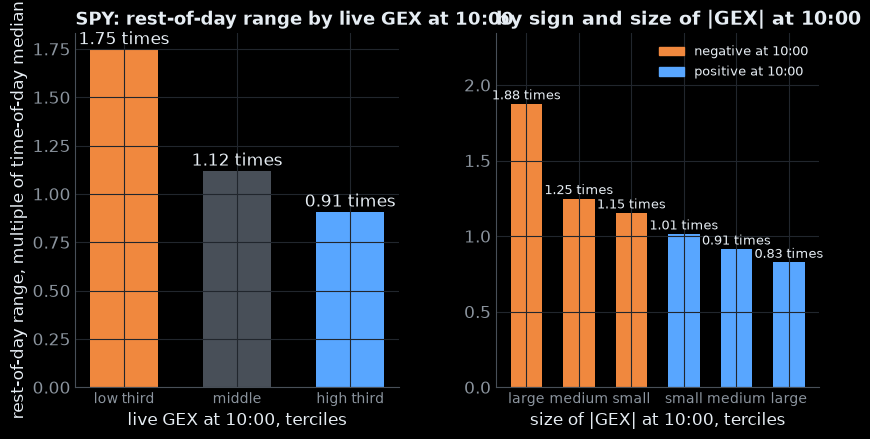

In [2]:
res = R.row2(ctx)
print(json.dumps({k: v for k, v in R.show(res).items() if 'horizon' not in k}, indent=1))
display(pd.DataFrame({t: {h: f'{a:+.2f} (stale {b:+.2f})' for h, (a, b) in d.items()} for t, d in res['spearman_by_time_and_horizon (live, stale)'].items()}).T)
_ = R.fig2(ctx, res, G.FIGURES / 'row02_level_at_1000.png')

Left: days are split into thirds by the live gamma reading at 10:00, and the bars show the average high-to-low range of SPY from 10:00 to the close in each third. Right: one typical day from the high third and one from the low third, plotted as the move from the open in percent, with the dotted line marking the 10:00 reading.

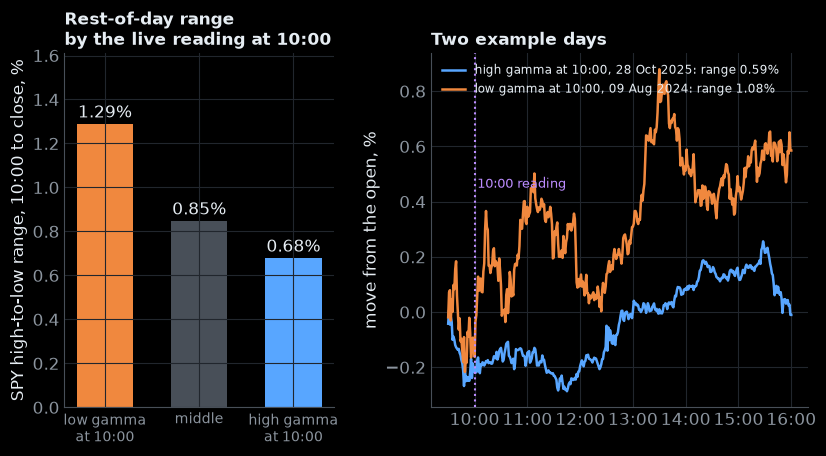

In [3]:
_ = R.fig_open2(ctx, res, G.FIGURES / 'row02_opener.png')

In [4]:
R.per_name({'r2_spearman_1000_rest': 'Spearman correlation, 10:00 level versus rest of day', 'r2_rest_low_third': 'rest-of-day range, low third (times the median)', 'r2_rest_high_third': 'rest-of-day range, high third'}).round(3)

,"Spearman correlation, 10:00 level versus rest of day","rest-of-day range, low third (times the median)","rest-of-day range, high third"
symbol,,,
SPY,-0.577,1.745,0.905
QQQ,-0.520,1.480,0.888
IWM,-0.251,1.339,1.052
NVDA,-0.179,1.236,1.112
TSLA,0.045,1.133,1.193
AAPL,-0.200,1.207,1.069
AMZN,-0.253,1.271,1.070
META,-0.152,1.145,1.086
MSFT,-0.179,1.201,1.063
